### Timing: Depending on the MALDI-MSI sampling spots number, 10 min - 6 h

Raw binary files generated by TIMS-TOF were first coverted into imzML format using SCiLS Lab software.

environment: uMAIA_env    
This notebook utilizes uMAIA to convert imzML file into AnnData file

In [1]:
import os

os.environ["MKL_NUM_THREADS"] = "16"
os.environ["NUMEXPR_NUM_THREADS"] = "16"
os.environ["OMP_NUM_THREADS"] = "16"

import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import uMAIA
from uMAIA.utils.tools import extract_image_coordinates
import pandas as pd
import tqdm

/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def visualize_ranges_test(smz, PF, clip=100, img_shape=None):
    """
    Extract images from the smzObj according to extracted ranges defined in df and save into AnnData object (.h5ad) format
    
    Args
    ----
    smz: smzObj
    PF: Peakcalling object
    clip: int, optional
        percentile to clip images
        default, no clipping
    """
    
    tic_pixels = np.array(smz.S.sum(axis=1)).flatten()
    
    if img_shape is None:
        img_shape = smz.img_shape

    image_list = {}
    for i, r in tqdm.tqdm(enumerate(PF.ranges), total=len(PF.ranges)):

        mz_select_ = (smz.mz_vals > r[0]) & (smz.mz_vals < r[1])
        S_select = smz.S[:,mz_select_].toarray()
        mz = smz.mz_vals[mz_select_]

        img = np.sum(S_select, axis=1)
        # tic normalization
        img = img / tic_pixels

        # clip to nth percentile
        percentile = np.percentile(img, clip)
        img = np.clip(img, 0, percentile)

        if img.shape[0] < np.multiply(*img_shape):
            img = extract_image_coordinates(smz.reader.coordinates, img_shape, img)
        else:
            img = img[:np.multiply(*img_shape)].reshape(img_shape)
            
        image_list[f'{np.mean(r):.5f}'] = img
    return image_list

In [3]:
# set parameters
mz_resolution = 1.67e-3 # Largest detected mz * 10 ppm (Depends on the instrument) * 10e-6 / 6, for instance: 1000 * 10 * 10e-6 / 6 = 1.67e-3
threshold_count = 8.

smz = uMAIA.ut.SmzMLobj("demo_data/MALDI/a3-8um-root mean square.ibd",
                           "demo_data/MALDI/a3-8um-root mean square.imzML",
                           mz_resolution=mz_resolution)

smz.load(load_unique_mz=True)
smz.S

/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000042 found with incorrect name "max count of pixel x". Updating name to "max count of pixels x".
  warn(
/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000043 found with incorrect name "max count of pixel y". Updating name to "max count of pixels y".
  warn(
/home/duan/miniconda3/envs/uMAIA_env/lib/python3.11/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(
Loading Spectra at resolution 0.00167: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34503/34503 [00:01<00:00, 19591.79it/s]
Loading the m/z values at resolution 0.00167: 34503it [00:02, 13

<34503x1121 sparse matrix of type '<class 'numpy.float64'>'
	with 20804992 stored elements in Compressed Sparse Column format>

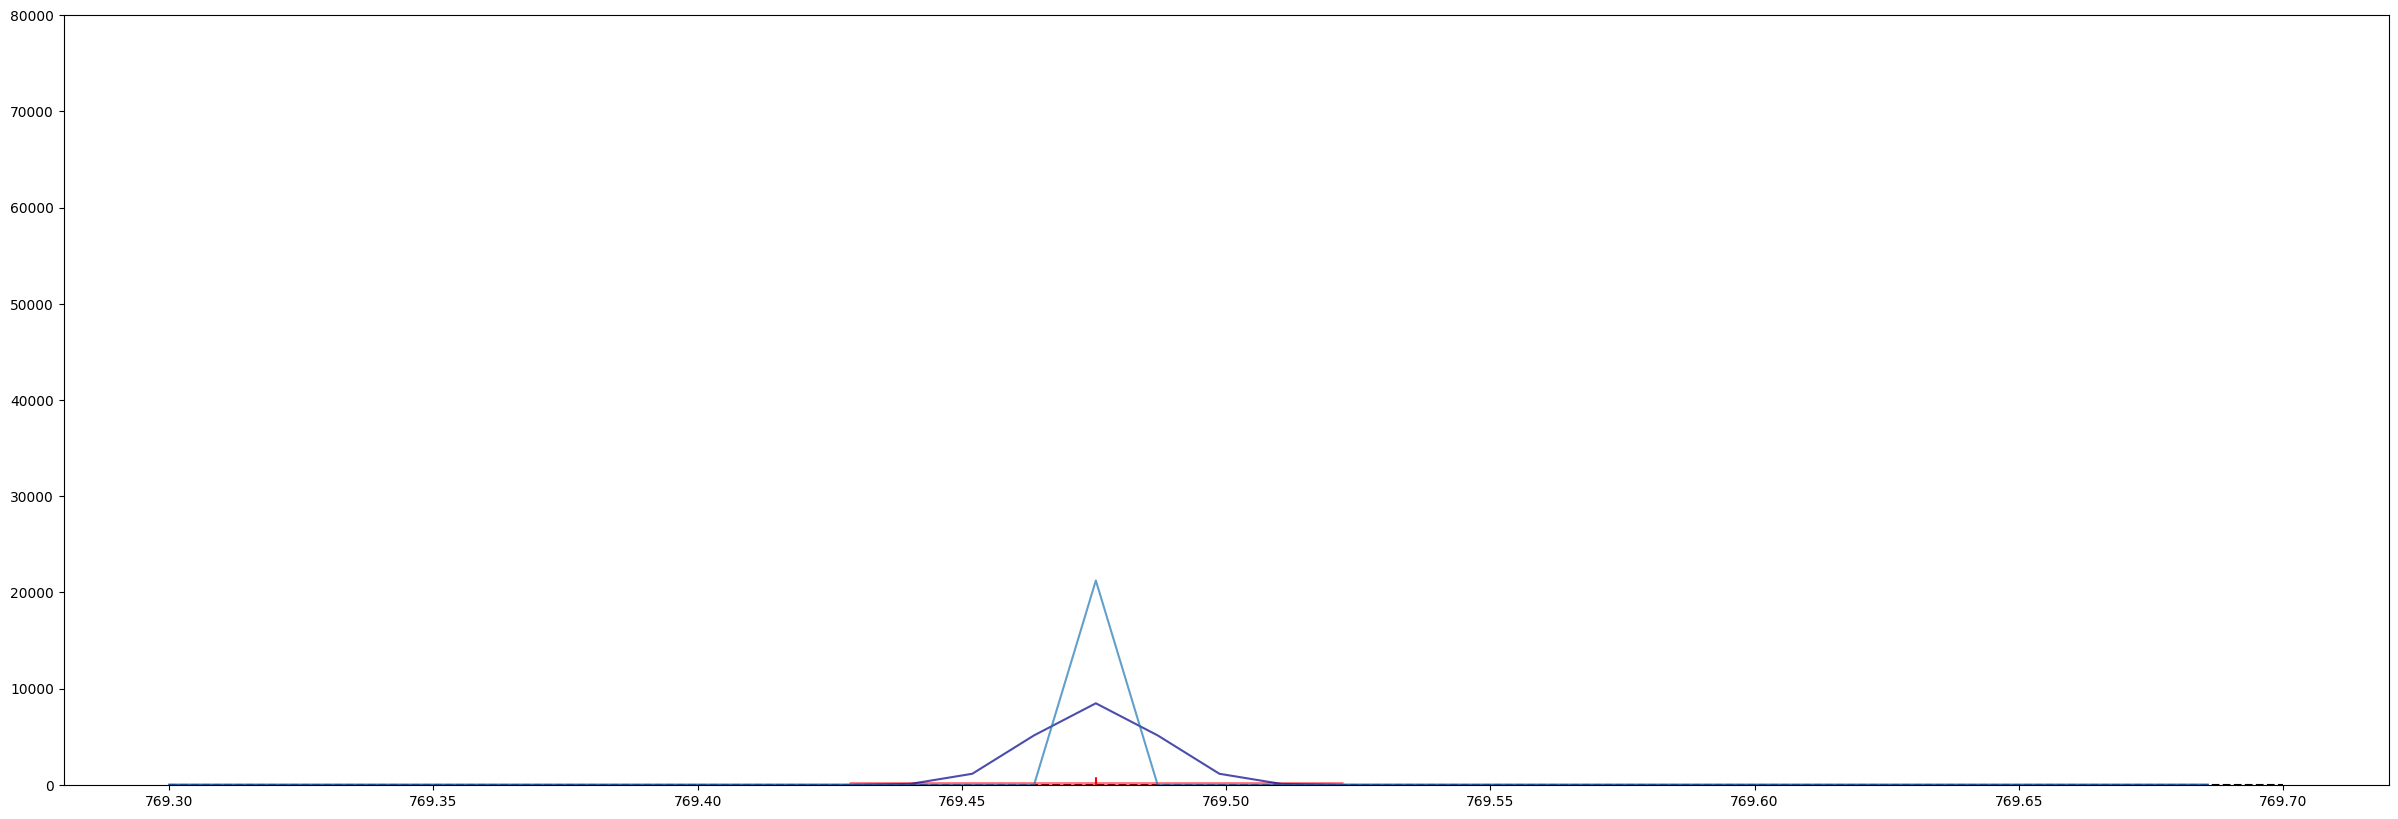

In [4]:
# smoothing on the frequency domain. for noisy mass errors, increase sigma, otherwise sigma can stay 
# a small value. use the plot_freqmz function to determine the best parameter for your dataset.
smoothing = 1.

# approximate interval refers to the size of the portion of the spectrum that is provided to the peak caller at a given instance
# if your machine throws an error, or the kernel stops, try decreasing this value
approximate_interval =.5


mzrange_test = np.array([769.3, 769.7]) # select a small window in the m/z spectrum that captures a reference compound
PF = uMAIA.vis.plot_freqmz(smz, 
                          mzrange_test, 
                          bins=True,
                          smoothing=smoothing, 
                          ylim=80000, 
                          threshold_count=threshold_count, 
                          approximate_interval=approximate_interval,
                          parallelize=True, 
                          mz_resolution=mz_resolution)

for m in PF.data_mz[PF.seeds]:
    plt.vlines(m, 0,1000,linestyle='--', color='r')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 51.29it/s]


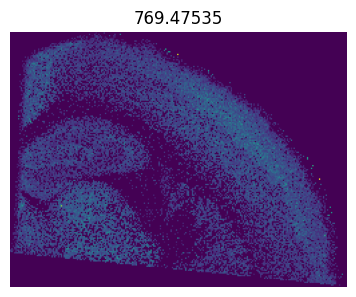

In [5]:
images = visualize_ranges_test(smz, PF)
fig = plt.figure(None, (20,10))
gs = plt.GridSpec(2,4)
for i, (mz, img) in enumerate(images.items()):
    plt.subplot(gs[i])
    plt.imshow(img)
    plt.title(mz)
    plt.axis('off')

In [6]:
uMAIA.pf.run(directory_path="demo_data/MALDI", # input directory for saving peak-called objects
            smz=smz, 
            spectrum_range=(50,1300), # indicate the mz spectrum you wish to image
            threshold_count=threshold_count, 
            approximate_interval=approximate_interval,
            smoothing=smoothing,
            parallelize=True,
            saveimages=True  # whether images should be saved automatically
            )

Partioning m/z space and beginning peakcalling...


  0%|                                                                                                                                                                                                                           | 0/501 [00:00<?, ?it/s]

invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_ran

  6%|████████████▌                                                                                                                                                                                                     | 30/501 [00:00<00:05, 89.69it/s]

invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range


...

invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
invalid mz_range
Creating dataframe...


  0%|                                                                                                                                                                                                                          | 0/2865 [00:00<?, ?it/s]/media/duan/sda2/MALDI/software/uMAIA/uMAIA/peak_finding/_run.py:213: RuntimeWarning: invalid value encountered in scalar divide
  percent_1_hit = np.sum(S_selected == 1.) / np.sum(S_selected >= 1.) * 100
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2865/2865 [00:03<00:00, 747.87it/s]


DataFrame created successfully
Removing temporary storage
Saving images...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1117/1117 [00:24<00:00, 46.41it/s]


Complete


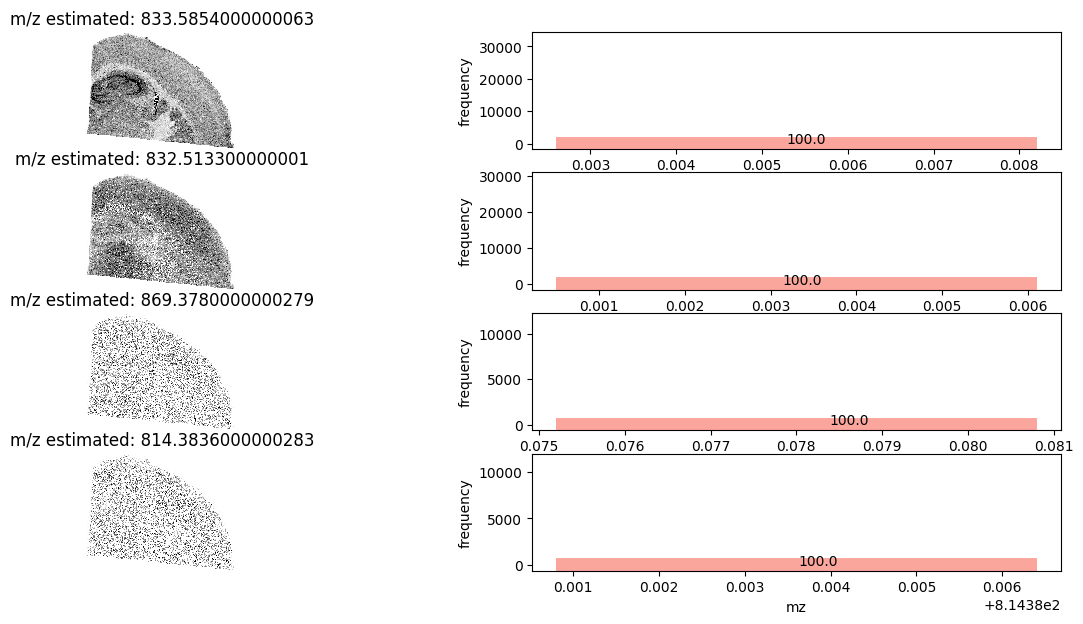

In [7]:
df_ranges = pd.read_csv("demo_data/MALDI/ranges.csv", index_col=0)

adduct_H = -1.007
adduct_Cl = 35.453
adduct_H2O= -18.0150-1.007
s_mz =833.5


fig, mz_images = uMAIA.vis.image_mz(smz, df=df_ranges, normalize = None,
                             mz_list=[s_mz, s_mz + adduct_H, s_mz + adduct_Cl, s_mz + adduct_H2O], 
                             cmap='Greys',figsize=(15,7),
                             img_shape=smz.img_shape, limit=0.01,clip=99,
                            )